# Load PRD MURA PyTorch model from MLflow and predict


In [ ]:
VPS_HOST = "<>"
MLFLOW_TRACKING_URI = f"http://{VPS_HOST}:8094"
REGISTERED_MODEL_NAME = "mura_dinov2_transformer"
MODEL_ALIAS = "prd"

IMG_SIZE = 448
DEFAULT_THRESHOLD = 0.5

MURA_ZIP_PATH = "/content/drive/MyDrive/Project2025/MURA-v1.1-resized-448x448.zip"
SAMPLE_STUDY_DIR = "/content/mura_predict_sample/MURA-v1.1-resized-448x448/valid/XR_SHOULDER/patient11417/study2_negative"
SAMPLE_IMAGE_PATH = ""
SAMPLE_ANATOMY = ""
MAX_DISPLAY_IMAGES = 16


In [8]:
%pip -q install "mlflow>=2.15.1,<3" "torch" "torchvision" "transformers>=4.45" "pandas" "numpy" "pillow" "boto3" "matplotlib"


In [9]:
from pathlib import Path
import math
import os
import zipfile
import shutil

import mlflow
import mlflow.pytorch
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from transformers import AutoModel
from mlflow.tracking import MlflowClient

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("device:", DEVICE)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MLflow tracking URI: http://64.226.117.149:8094
device: cuda


In [10]:
def find_mura_root(extract_dir: Path) -> Path:
    candidates = [extract_dir / "MURA-v1.1", extract_dir]
    candidates.extend([p for p in extract_dir.rglob("*") if p.is_dir() and p.name == "MURA-v1.1"])
    for candidate in candidates:
        if (candidate / "train").is_dir() and (candidate / "valid").is_dir():
            return candidate
    for candidate in extract_dir.rglob("*"):
        if candidate.is_dir() and (candidate / "train").is_dir() and (candidate / "valid").is_dir():
            return candidate
    raise FileNotFoundError("Could not find MURA-v1.1 root")


IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp"}


def is_real_image_file(path: Path) -> bool:
    if path.suffix.lower() not in IMAGE_EXTENSIONS:
        return False
    if path.name.startswith("._") or path.name == ".DS_Store":
        return False
    if "__MACOSX" in path.parts:
        return False
    return True


def infer_anatomy(path: str) -> str:
    for part in Path(path).parts:
        if part.startswith("XR_"):
            return part
    raise ValueError(f"Cannot infer anatomy from {path}")


def list_study_images(study_dir: str | Path) -> list[Path]:
    study_path = Path(study_dir)
    if not study_path.is_dir():
        raise NotADirectoryError(f"Study directory not found: {study_path}")
    image_paths = sorted(p for p in study_path.rglob("*") if p.is_file() and is_real_image_file(p))
    if not image_paths:
        raise RuntimeError(f"No image files found in study directory: {study_path}")
    return image_paths


def get_sample_image() -> tuple[str, str]:
    if SAMPLE_IMAGE_PATH:
        anatomy = SAMPLE_ANATOMY or infer_anatomy(SAMPLE_IMAGE_PATH)
        return SAMPLE_IMAGE_PATH, anatomy

    zip_path = Path(MURA_ZIP_PATH)
    if not zip_path.exists():
        alt_paths = [
            Path("/content/MURA-v1.1-resized-448x448.zip"),
            Path("/content/MURA-v1.1.zip"),
        ]
        zip_path = next((p for p in alt_paths if p.exists()), None)
        if zip_path is None:
            raise FileNotFoundError("Set SAMPLE_IMAGE_PATH or put a MURA zip at MURA_ZIP_PATH, /content/MURA-v1.1-resized-448x448.zip, or /content/MURA-v1.1.zip")

    extract_dir = Path("/content/mura_predict_sample")
    marker = extract_dir / ".done"
    if not marker.exists():
        if extract_dir.exists():
            shutil.rmtree(extract_dir)
        extract_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_dir)
        marker.write_text(str(zip_path))
    root = find_mura_root(extract_dir)
    image_path = next(p for p in (root / "valid").rglob("*") if p.is_file() and is_real_image_file(p))
    return str(image_path), infer_anatomy(str(image_path))


def get_sample_study_dir(sample_image_path: str) -> str:
    if SAMPLE_STUDY_DIR:
        list_study_images(SAMPLE_STUDY_DIR)
        return SAMPLE_STUDY_DIR
    return str(Path(sample_image_path).parent)


if SAMPLE_STUDY_DIR:
    study_dir = get_sample_study_dir("")
    image_path = str(list_study_images(study_dir)[0])
    anatomy = SAMPLE_ANATOMY or infer_anatomy(study_dir)
else:
    image_path, anatomy = get_sample_image()
    study_dir = get_sample_study_dir(image_path)
print("sample image:", image_path, anatomy)
print("sample study:", study_dir)


sample image: /content/mura_predict_sample/MURA-v1.1-resized-448x448/valid/XR_SHOULDER/patient11417/study2_negative/image1.png XR_SHOULDER
sample study: /content/mura_predict_sample/MURA-v1.1-resized-448x448/valid/XR_SHOULDER/patient11417/study2_negative


In [11]:
class SquarePadResize:
    def __init__(self, size: int, fill: int = 0):
        self.size = size
        self.fill = fill

    def __call__(self, image: Image.Image) -> Image.Image:
        image = image.convert("RGB")
        w, h = image.size
        scale = self.size / max(w, h)
        new_w = max(1, int(round(w * scale)))
        new_h = max(1, int(round(h * scale)))
        image = image.resize((new_w, new_h), Image.BICUBIC)
        canvas = Image.new("RGB", (self.size, self.size), color=(self.fill, self.fill, self.fill))
        canvas.paste(image, ((self.size - new_w) // 2, (self.size - new_h) // 2))
        return canvas


class MuraDinoClassifier(nn.Module):
    def __init__(self, model_name: str, bone_categories: list[str], dropout: float = 0.30):
        super().__init__()
        self.model_name = model_name
        self.bone_categories = list(bone_categories)
        self.dino = AutoModel.from_pretrained(model_name)
        hidden_size = int(self.dino.config.hidden_size)
        self.feature_dim = hidden_size * 2
        self.head = nn.Sequential(
            nn.Linear(self.feature_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(0.20),
        )
        self.classifiers = nn.ModuleDict({bone: nn.Linear(128, 2) for bone in self.bone_categories})
        self.freeze_backbone()

    def freeze_backbone(self) -> None:
        for p in self.dino.parameters():
            p.requires_grad = False

    def transformer_layers(self):
        if hasattr(self.dino, "encoder") and hasattr(self.dino.encoder, "layer"):
            return list(self.dino.encoder.layer)
        raise AttributeError("Unsupported DINO backbone: cannot find dino.encoder.layer")

    def set_trainable_last_n_blocks(self, n_blocks: int) -> None:
        self.freeze_backbone()
        if n_blocks <= 0:
            return
        layers = self.transformer_layers()
        for layer in layers[-n_blocks:]:
            for p in layer.parameters():
                p.requires_grad = True

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        outputs = self.dino(pixel_values=x)
        tokens = outputs.last_hidden_state
        cls_token = tokens[:, 0, :]
        patch_mean = tokens[:, 1:, :].mean(dim=1)
        return self.head(torch.cat([cls_token, patch_mean], dim=1))

    def forward(self, x: torch.Tensor, anatomies) -> torch.Tensor:
        feat = self.forward_features(x)
        logits = torch.empty((x.size(0), 2), dtype=feat.dtype, device=feat.device)
        anatomies = list(anatomies)
        for bone in sorted(set(anatomies)):
            idx = [i for i, value in enumerate(anatomies) if value == bone]
            idx_t = torch.tensor(idx, dtype=torch.long, device=feat.device)
            logits[idx_t] = self.classifiers[bone](feat[idx_t])
        return logits


MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
eval_transform = transforms.Compose([
    SquarePadResize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])


def get_prd_model_version(client: MlflowClient):
    return client.get_model_version_by_alias(REGISTERED_MODEL_NAME, MODEL_ALIAS)


def get_threshold(client: MlflowClient, model_version) -> float:
    if not model_version.run_id:
        return float(DEFAULT_THRESHOLD)
    run = client.get_run(model_version.run_id)
    return float(run.data.metrics.get("final/best_threshold", DEFAULT_THRESHOLD))


def load_registered_pytorch_model(model_uri: str) -> nn.Module:
    try:
        loaded_model = mlflow.pytorch.load_model(model_uri, map_location=DEVICE, weights_only=False)
    except TypeError:
        loaded_model = mlflow.pytorch.load_model(model_uri, map_location=DEVICE)
    loaded_model.to(DEVICE)
    loaded_model.eval()
    return loaded_model


def known_anatomies(model: nn.Module) -> set[str]:
    if hasattr(model, "bone_categories"):
        return set(model.bone_categories)
    if hasattr(model, "classifiers"):
        return set(model.classifiers.keys())
    return set()


def predict_images(model: nn.Module, input_df: pd.DataFrame, threshold: float) -> pd.DataFrame:
    required = {"image_path", "anatomy"}
    missing = required - set(input_df.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")

    images = []
    anatomies = []
    for _, row in input_df.iterrows():
        image = Image.open(row["image_path"]).convert("L")
        images.append(eval_transform(image))
        anatomies.append(str(row["anatomy"]))

    allowed = known_anatomies(model)
    unknown = sorted(set(anatomies) - allowed) if allowed else []
    if unknown:
        raise ValueError(f"Unknown anatomy values for this model: {unknown}. Known values: {sorted(allowed)}")

    batch = torch.stack(images).to(DEVICE)
    with torch.inference_mode():
        logits = model(batch, anatomies)
        probs = torch.softmax(logits.float(), dim=1)[:, 1].detach().cpu().numpy()

    return pd.DataFrame({
        "probability": probs,
        "prediction": (probs >= threshold).astype(int),
        "threshold": threshold,
    })


def build_study_input_frame(study_dir: str | Path) -> pd.DataFrame:
    image_paths = list_study_images(study_dir)
    anatomy = SAMPLE_ANATOMY or infer_anatomy(str(study_dir))
    return pd.DataFrame({
        "image_path": [str(path) for path in image_paths],
        "anatomy": anatomy,
    })


def aggregate_study_prediction(image_results: pd.DataFrame, study_dir: str | Path, threshold: float) -> pd.DataFrame:
    probability = float(image_results["probability"].mean())
    return pd.DataFrame({
        "study_dir": [str(study_dir)],
        "anatomy": [str(image_results["anatomy"].iloc[0])],
        "n_images": [int(len(image_results))],
        "probability": [probability],
        "prediction": [int(probability >= threshold)],
        "threshold": [threshold],
    })


def show_study_images(image_results: pd.DataFrame, max_images: int = MAX_DISPLAY_IMAGES) -> None:
    shown = image_results.head(max_images).reset_index(drop=True)
    if shown.empty:
        return
    cols = min(4, len(shown))
    rows = math.ceil(len(shown) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes_list = [axes] if len(shown) == 1 else list(axes.flat)
    for ax, (_, row) in zip(axes_list, shown.iterrows()):
        image = Image.open(row["image_path"]).convert("L")
        ax.imshow(image, cmap="gray")
        ax.set_title(f"{Path(row['image_path']).name}\nprob={row['probability']:.3f} pred={int(row['prediction'])}")
        ax.axis("off")
    for ax in axes_list[len(shown):]:
        ax.axis("off")
    if len(image_results) > len(shown):
        fig.suptitle(f"Showing {len(shown)} of {len(image_results)} study images")
    plt.tight_layout()
    plt.show()

print("PyTorch inference helpers ready")


PyTorch inference helpers ready


model uri: models:/mura_dinov2_transformer@prd
model version: 2
run id: 5c9be40a2abf43d49b304742376ec034
threshold: 0.48
known anatomies: ['XR_ELBOW', 'XR_FINGER', 'XR_FOREARM', 'XR_HAND', 'XR_HUMERUS', 'XR_SHOULDER', 'XR_WRIST']


,study_dir,anatomy,n_images,probability,prediction,threshold
0,/content/mura_predict_sample/MURA-v1.1-resized...,XR_SHOULDER,3,0.261775,0,0.48


,image_path,anatomy,probability,prediction,threshold
0,/content/mura_predict_sample/MURA-v1.1-resized...,XR_SHOULDER,0.311773,0,0.48
1,/content/mura_predict_sample/MURA-v1.1-resized...,XR_SHOULDER,0.142693,0,0.48
2,/content/mura_predict_sample/MURA-v1.1-resized...,XR_SHOULDER,0.330858,0,0.48


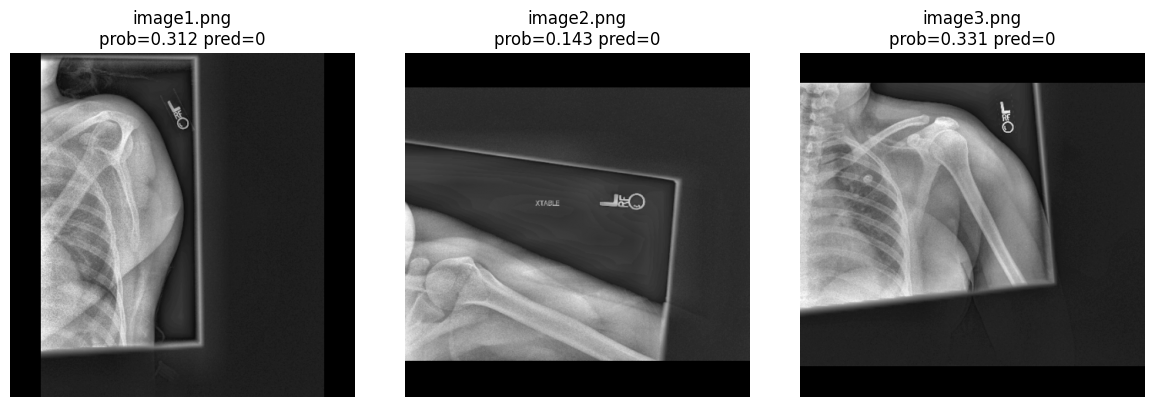

In [12]:
client = MlflowClient()
model_version = get_prd_model_version(client)
model_uri = f"models:/{REGISTERED_MODEL_NAME}@{MODEL_ALIAS}"
threshold = get_threshold(client, model_version)
model = load_registered_pytorch_model(model_uri)

print("model uri:", model_uri)
print("model version:", model_version.version)
print("run id:", model_version.run_id)
print("threshold:", threshold)
print("known anatomies:", sorted(known_anatomies(model)))

study_input_df = build_study_input_frame(study_dir)
image_pred = predict_images(model, study_input_df, threshold)
image_results = pd.concat([study_input_df, image_pred], axis=1)
study_result = aggregate_study_prediction(image_results, study_dir, threshold)

display(study_result)
display(image_results)
show_study_images(image_results)
